In [17]:
import pandas as pd
import numpy as np
import plotly.express as px

In [10]:
df = pd.read_csv('../data/demanddata_2024.csv')
#print(df.head())

df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%d-%b-%Y')

# Create a single datetime column combining date and settlement period
# Each period is 30 minutes, period 1 starts at 00:00
df['datetime'] = df['SETTLEMENT_DATE'] + pd.to_timedelta((df['SETTLEMENT_PERIOD'] - 1) * 30, unit='m')

df = df.set_index('datetime')
df = df.sort_index()


  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0     01-JAN-2024                  1  21783  23466                 19539   
1     01-JAN-2024                  2  22521  24103                 20286   
2     01-JAN-2024                  3  22194  24754                 20070   
3     01-JAN-2024                  4  21510  24505                 19424   
4     01-JAN-2024                  5  20619  23977                 18674   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                      2804                    6488   
1                      2834                    6488   
2                      2868                    6488   
3                      2901                    6488   
4                      2933                    6488   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                    16793            0  ...   
1                          0                    16793         

In [21]:
# Create indexes for hour of day, day_of_week, month of year, and boolean for if weekend day or not
df['hour'] = df.index.hour
df['day_of_week'] = df.index.day_of_week
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'] >= 5
#print(df.head())

In [24]:
# Naive forecast - forecast for this Mondays demand is last Mondays demand

# Create column of shifted demand data to use as forecast
# Use numpy roll to shift data 'round the clock' to avoid NaN values
df['ND_lagged'] = df['ND'].shift(336)

#Check lagging
#print(df['ND_lagged'][336:338])
#print(df['ND'][0:2])



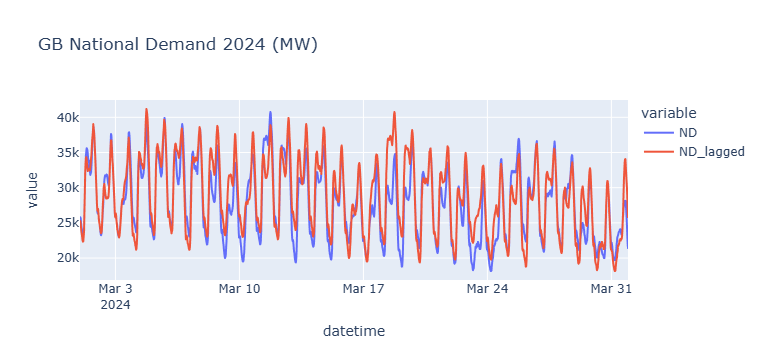

1968.276752553389
2597.5327769059513


In [30]:
# Calculate error metrics

df_clean = df.dropna()

# Mean Absolute Error
mae = np.mean(np.abs(df['ND'] - df['ND_lagged']))

# Root Mean Square error
RMSE = np.sqrt(np.mean((df['ND'] - df['ND_lagged'])**2))



# Plot lines
march_df = df[df['month']==3]
fig1 = px.line(march_df, y=['ND', 'ND_lagged'], title='GB National Demand 2024 (MW)')
fig1.show()

print(mae)
print(RMSE)